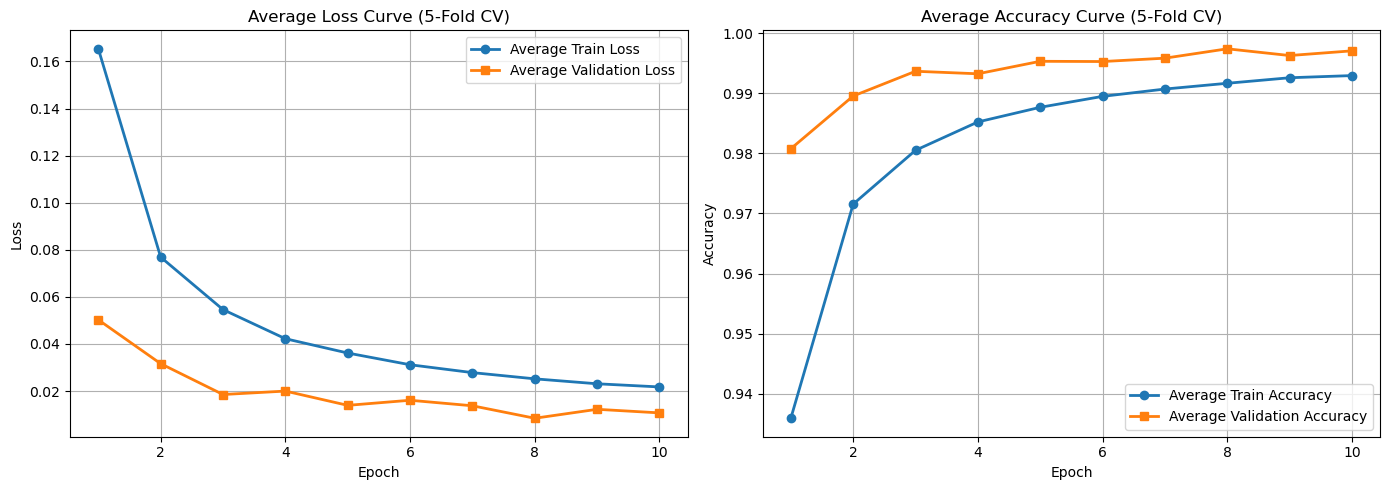


Average Confusion Matrix:
[[16144.     30.4]
 [   58.2 14559.4]]


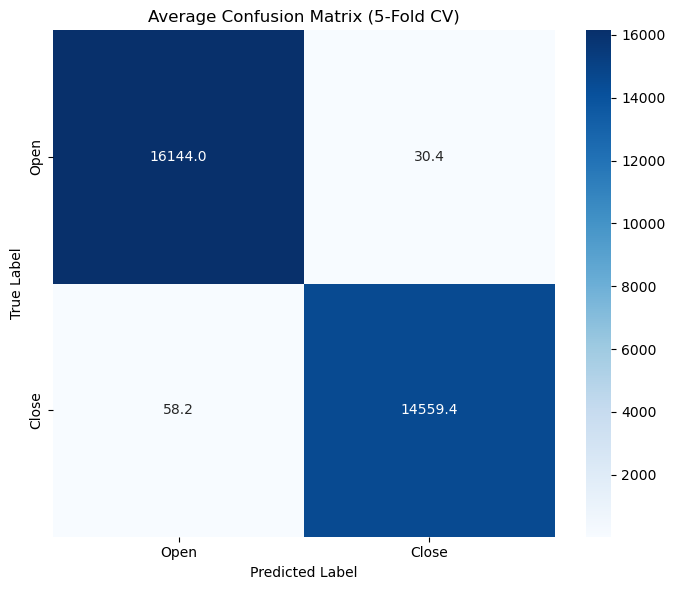


Global Confusion Matrix:
[[80720   152]
 [  291 72797]]


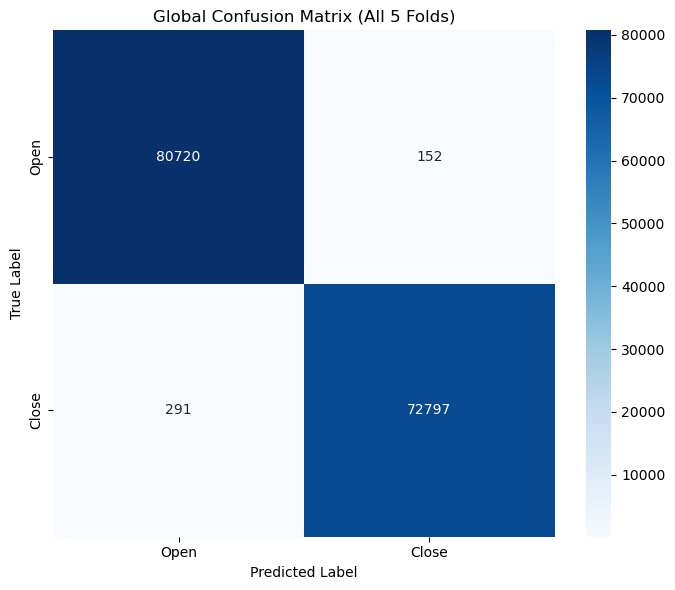

In [1]:
# ==========================================================
# AVERAGE ACCURACY CURVE, LOSS CURVE & CONFUSION MATRIX
# FOR 5-FOLD CROSS VALIDATION
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================================
# TRAIN LOSS
# ==========================================================

train_loss = np.array([
    [0.1778,0.0836,0.0595,0.0479,0.0409,0.0364,0.0335,0.0301,0.0256,0.0247],
    [0.1627,0.0723,0.0523,0.0409,0.0335,0.0289,0.0262,0.0245,0.0225,0.0205],
    [0.1611,0.0749,0.0531,0.0411,0.0356,0.0305,0.0276,0.0232,0.0226,0.0204],
    [0.1670,0.0810,0.0572,0.0433,0.0365,0.0314,0.0265,0.0253,0.0234,0.0221],
    [0.1582,0.0726,0.0509,0.0380,0.0343,0.0287,0.0254,0.0229,0.0214,0.0211]
])

# ==========================================================
# VALIDATION LOSS
# ==========================================================

val_loss = np.array([
    [0.0407,0.0459,0.0207,0.0156,0.0194,0.0358,0.0106,0.0075,0.0138,0.0076],
    [0.0433,0.0244,0.0172,0.0190,0.0095,0.0138,0.0167,0.0074,0.0083,0.0114],
    [0.0671,0.0293,0.0171,0.0137,0.0127,0.0101,0.0166,0.0090,0.0076,0.0099],
    [0.0534,0.0276,0.0189,0.0307,0.0118,0.0090,0.0088,0.0083,0.0093,0.0080],
    [0.0468,0.0310,0.0188,0.0210,0.0163,0.0118,0.0161,0.0101,0.0223,0.0168]
])

# ==========================================================
# TRAIN ACCURACY
# ==========================================================

train_acc = np.array([
    [0.9296,0.9674,0.9784,0.9826,0.9854,0.9875,0.9883,0.9898,0.9917,0.9921],
    [0.9375,0.9741,0.9816,0.9860,0.9890,0.9904,0.9912,0.9920,0.9927,0.9934],
    [0.9390,0.9723,0.9811,0.9861,0.9880,0.9898,0.9909,0.9923,0.9929,0.9936],
    [0.9339,0.9704,0.9798,0.9849,0.9875,0.9893,0.9915,0.9918,0.9925,0.9927],
    [0.9395,0.9736,0.9817,0.9866,0.9885,0.9905,0.9917,0.9925,0.9932,0.9930]
])

# ==========================================================
# VALIDATION ACCURACY
# ==========================================================

val_acc = np.array([
    [0.9850,0.9826,0.9908,0.9949,0.9928,0.9893,0.9964,0.9977,0.9946,0.9977],
    [0.9858,0.9923,0.9943,0.9936,0.9976,0.9964,0.9945,0.9981,0.9979,0.9976],
    [0.9705,0.9904,0.9949,0.9957,0.9950,0.9975,0.9945,0.9972,0.9977,0.9969],
    [0.9788,0.9916,0.9943,0.9880,0.9971,0.9975,0.9977,0.9973,0.9971,0.9980],
    [0.9838,0.9909,0.9941,0.9941,0.9942,0.9958,0.9962,0.9968,0.9942,0.9952]
])

# ==========================================================
# AVERAGE CURVES
# ==========================================================

avg_train_loss = train_loss.mean(axis=0)
avg_val_loss = val_loss.mean(axis=0)

avg_train_acc = train_acc.mean(axis=0)
avg_val_acc = val_acc.mean(axis=0)

epochs = np.arange(1, 11)

# ==========================================================
# PLOT AVERAGE LOSS & ACCURACY
# ==========================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(epochs, avg_train_loss, marker='o',
             linewidth=2, label='Average Train Loss')
axes[0].plot(epochs, avg_val_loss, marker='s',
             linewidth=2, label='Average Validation Loss')

axes[0].set_title('Average Loss Curve (5-Fold CV)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(epochs, avg_train_acc, marker='o',
             linewidth=2, label='Average Train Accuracy')
axes[1].plot(epochs, avg_val_acc, marker='s',
             linewidth=2, label='Average Validation Accuracy')

axes[1].set_title('Average Accuracy Curve (5-Fold CV)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# ==========================================================
# CONFUSION MATRICES OF 5 FOLDS
# ==========================================================

cm1 = np.array([[16027, 60],
                [21, 14684]])

cm2 = np.array([[16250, 21],
                [54, 14467]])

cm3 = np.array([[16139, 18],
                [57, 14578]])

cm4 = np.array([[16250, 34],
                [32, 14476]])

cm5 = np.array([[16054, 19],
                [127, 14592]])

cms = [cm1, cm2, cm3, cm4, cm5]

# ==========================================================
# AVERAGE CONFUSION MATRIX
# ==========================================================

avg_cm = np.mean(cms, axis=0)

print("\nAverage Confusion Matrix:")
print(avg_cm)

plt.figure(figsize=(7,6))
sns.heatmap(
    avg_cm,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    xticklabels=['Open', 'Close'],
    yticklabels=['Open', 'Close']
)

plt.title('Average Confusion Matrix (5-Fold CV)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# ==========================================================
# GLOBAL CONFUSION MATRIX (RECOMMENDED FOR PAPERS)
# ==========================================================

global_cm = np.sum(cms, axis=0)

print("\nGlobal Confusion Matrix:")
print(global_cm)

plt.figure(figsize=(7,6))
sns.heatmap(
    global_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Open', 'Close'],
    yticklabels=['Open', 'Close']
)

plt.title('Global Confusion Matrix (All 5 Folds)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()